## Part 1: Exploratory data analysis and statistical testing

### Clean and pre-process the dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
#load the train and test datasets
train_df=pd.read_csv("adult-modified.data")
test_df=pd.read_csv("adult-modified.test")

In [3]:
#data types
train_df.dtypes

age                int64
workclass         object
fnlwgt             int64
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

In [4]:
train_df.columns

Index(['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [5]:
train_df.head(2)

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,5,United-States,<=50K
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,2,United-States,<=50K


In [6]:
#Number of rows
print("The number of rows in the dataframe:", train_df.shape[0])
#The number of columns
print("The number of columns in the dataframe:", train_df.shape[1])
#The number of datapoints
print("The number of datapoints in the dataframe:", train_df.shape[0]*train_df.shape[1])

The number of rows in the dataframe: 32561
The number of columns in the dataframe: 14
The number of datapoints in the dataframe: 455854


In [7]:
#define missing values
missing_values=["n/a", "na","--", ' ', "?"]

adult_df=pd.read_csv("adult-modified.data",na_values=missing_values)
adult_test=pd.read_csv("adult-modified.test", na_values=missing_values)

#sum of missing values
print("Sum of defined missing values per column (train data):")
adult_df.isnull().sum()

Sum of defined missing values per column (train data):


age                  0
workclass         1836
fnlwgt               0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [8]:
adult_test.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [9]:
#Find the percentage of missing values in the columns
cols=['workclass','occupation','native-country']
missing_percentage=adult_df[cols].isnull().sum()/adult_df.shape[0]*100

print("missing values per column (train data)")
print(missing_percentage)

missing values per column (train data)
workclass         5.638647
occupation        5.660146
native-country    1.790486
dtype: float64


In [10]:
#Find the percentage of missing values in the columns
cols=['workclass','occupation','native-country']
missing_percentage=adult_test[cols].isnull().sum()/adult_test.shape[0]*100

print("missing values per column (test data)")
print(missing_percentage)

missing values per column (test data)
workclass         5.914870
occupation        5.933296
native-country    1.682943
dtype: float64


In [11]:
#Handle the missing categorical values; replace them with the mode or "most frequent" 
import sklearn
from sklearn.impute import SimpleImputer

cols=["workclass", "occupation", "native-country"]

#define missing values 
missing_values=["n/a", "na","--", ' ', "?"]

#Turn all missing values to np.nan
adult_df[cols]=adult_df[cols].replace(missing_values, np.nan)
adult_test[cols]=adult_test[cols].replace(missing_values, np.nan)

#Replace missing values with the most frequent value in each column
imputer=SimpleImputer(missing_values=np.nan,strategy='most_frequent')

adult_df[cols]=imputer.fit_transform(adult_df[cols])
adult_test[cols]=imputer.fit_transform(adult_test[cols])

#Confirm there are no missing values
print("Missing values in the train data?",adult_df.isnull().values.any())
print("Missing values in the test data?",adult_test.isnull().values.any())

Missing values in the train data? False
Missing values in the test data? False


In [12]:
#Check for duplicated rows
duplicates=adult_df.duplicated()
duplicates_test=adult_test.duplicated()

num_duplicates=duplicates.sum()
num_duplicates_test=duplicates_test.sum()

print(f"Number of duplicate rows in train data:{num_duplicates}")
print(f"Number of duplicate rows in test data:{num_duplicates_test}")

#delete dupicate rows
adult_df=adult_df.drop_duplicates()
adult_test=adult_test.drop_duplicates()

Number of duplicate rows in train data:29
Number of duplicate rows in test data:8


In [13]:
# The number of people who make more and less than 50k a year
greater=adult_df["income"].value_counts()['>50K']
less=adult_df["income"].value_counts()['<=50K']

print("People earning greater than 50k annually:", greater)
print("People earning less than 50k annually:", less)

People earning greater than 50k annually: 7839
People earning less than 50k annually: 24693


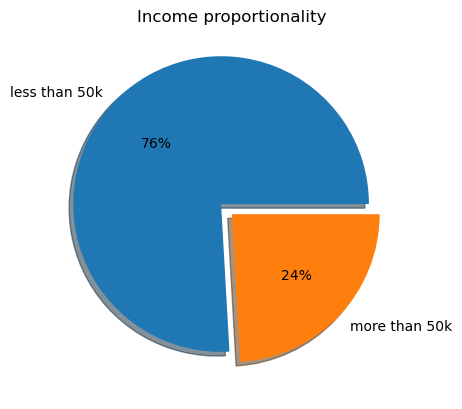

In [14]:
#visualise target variable "income"
import matplotlib.pyplot as plt
import seaborn as sns
explode=(0.1,0)

plt.pie(adult_df['income'].value_counts(), explode=explode,labels=['less than 50k','more than 50k'],autopct='%.f%%', shadow=True)
plt.title('Income proportionality')
plt.show()

In [15]:
print("\n Proportion of income in the train data\n",adult_test['income'].value_counts())


 Proportion of income in the train data
 income
<=50K.    12427
>50K.      3846
Name: count, dtype: int64


In [16]:
adult_df['native-country'].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', 'Mexico', 'South',
       'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany', 'Iran',
       'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [17]:
adult_df['native-country'].nunique()

41

In [18]:
#Define continent groups and map countries into continents
north_america = ['United-States','Canada','Mexico','Cuba','Jamaica','Puerto-Rico','Honduras',
                 'Dominican-Republic','El-Salvador','Guatemala','Nicaragua','Haiti','Trinadad&Tobago',
                 'Outlying-US(Guam-USVI-etc)']

south_america = ['Columbia','Ecuador','Peru']

europe = ['Germany','Italy','Poland','Portugal','France','Greece','Yugoslavia','Hungary','Holand-Netherlands','Engand', 'Scotland', 'Ireland']

asia = ['India','Iran','Philippines','Cambodia','Thailand','Laos','Taiwan','China','Japan','Vietnam','Hong','South']

def map_continent(country):
    if country in north_america:
        return 'North America'
    elif country in south_america:
        return 'South America'
    elif country in europe:
        return 'Europe'
    elif country in asia:
        return 'Asia'

adult_df['Continent']=adult_df['native-country'].apply(map_continent)
adult_test['Continent']=adult_test['native-country'].apply(map_continent)

#drop 'native-country' column
adult_df=adult_df.drop('native-country', axis=1)
adult_test=adult_test.drop('native-country',axis=1)

In [19]:
adult_df['Continent'].nunique()

4

In [20]:
#convert income and zex column to binary form
pd.set_option('future.no_silent_downcasting',True)

#binarisation of income and gender
target={'<=50K':0,'>50K':1}
adult_df['income_binary']=adult_df['income'].replace(target).astype(int)

gender={'Male':0,'Female':1}
adult_df['sex_binary']=adult_df['sex'].replace(gender).astype(int)

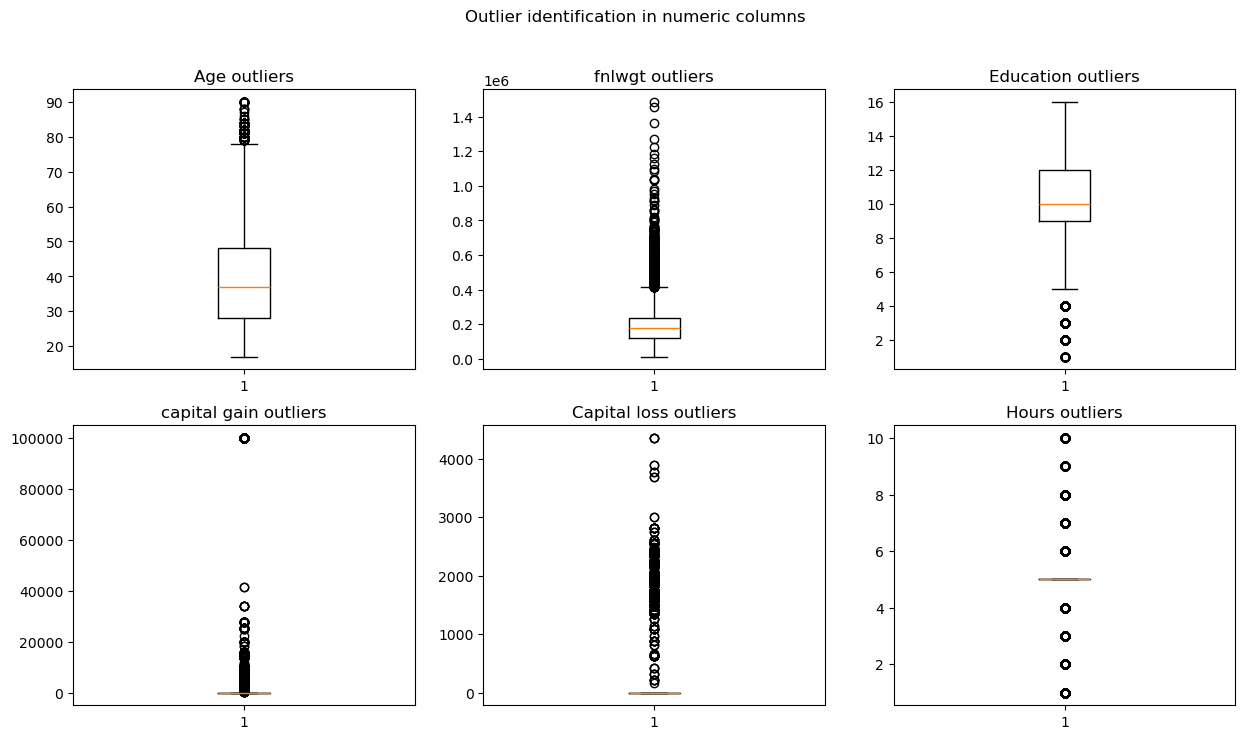

In [21]:
#outliers: Visualise outliers in numerical columns using boxplots
fig,axes=plt.subplots(2,3,figsize=(15,8))
axes=axes.flatten()

#plot each column
axes[0].boxplot(adult_df["age"])
axes[0].set_title("Age outliers")

axes[1].boxplot(adult_df["fnlwgt"])
axes[1].set_title("fnlwgt outliers")

axes[2].boxplot(adult_df["education-num"])
axes[2].set_title("Education outliers")

axes[3].boxplot(adult_df["capital-gain"])
axes[3].set_title("capital gain outliers")

axes[4].boxplot(adult_df["capital-loss"])
axes[4].set_title("Capital loss outliers")

axes[5].boxplot(adult_df["hours-per-week"])
axes[5].set_title("Hours outliers")

#add a main title
fig.suptitle("Outlier identification in numeric columns")

plt.tight_layout
plt.show()

### Descriptive statistics

In [22]:
adult_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income_binary,sex_binary
count,32532.000000,3.253200e+04,32532.000000,32532.000000,32532.000000,32532.000000,32532.000000,32532.000000
mean,38.588559,1.897854e+05,10.081919,1078.609492,87.381655,4.836161,0.240963,0.330690
std,13.636858,1.055628e+05,2.571774,7388.513066,403.131355,1.158900,0.427674,0.470469
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,28.000000,1.178242e+05,9.000000,0.000000,0.000000,5.000000,0.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,5.000000,0.000000,0.000000
75%,48.000000,2.370065e+05,12.000000,0.000000,0.000000,5.000000,0.000000,1.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,10.000000,1.000000,1.000000


In [23]:
adult_df.describe(include=["object"])

,workclass,marital-status,occupation,relationship,race,sex,income,Continent
count,32532,32532,32532,32532,32532,32532,32532,32442
unique,8,7,14,6,5,2,2,4
top,Private,Married-civ-spouse,Prof-specialty,Husband,White,Male,<=50K,North America
freq,24504,14970,5977,13187,27790,21774,24693,31142


### Normality test

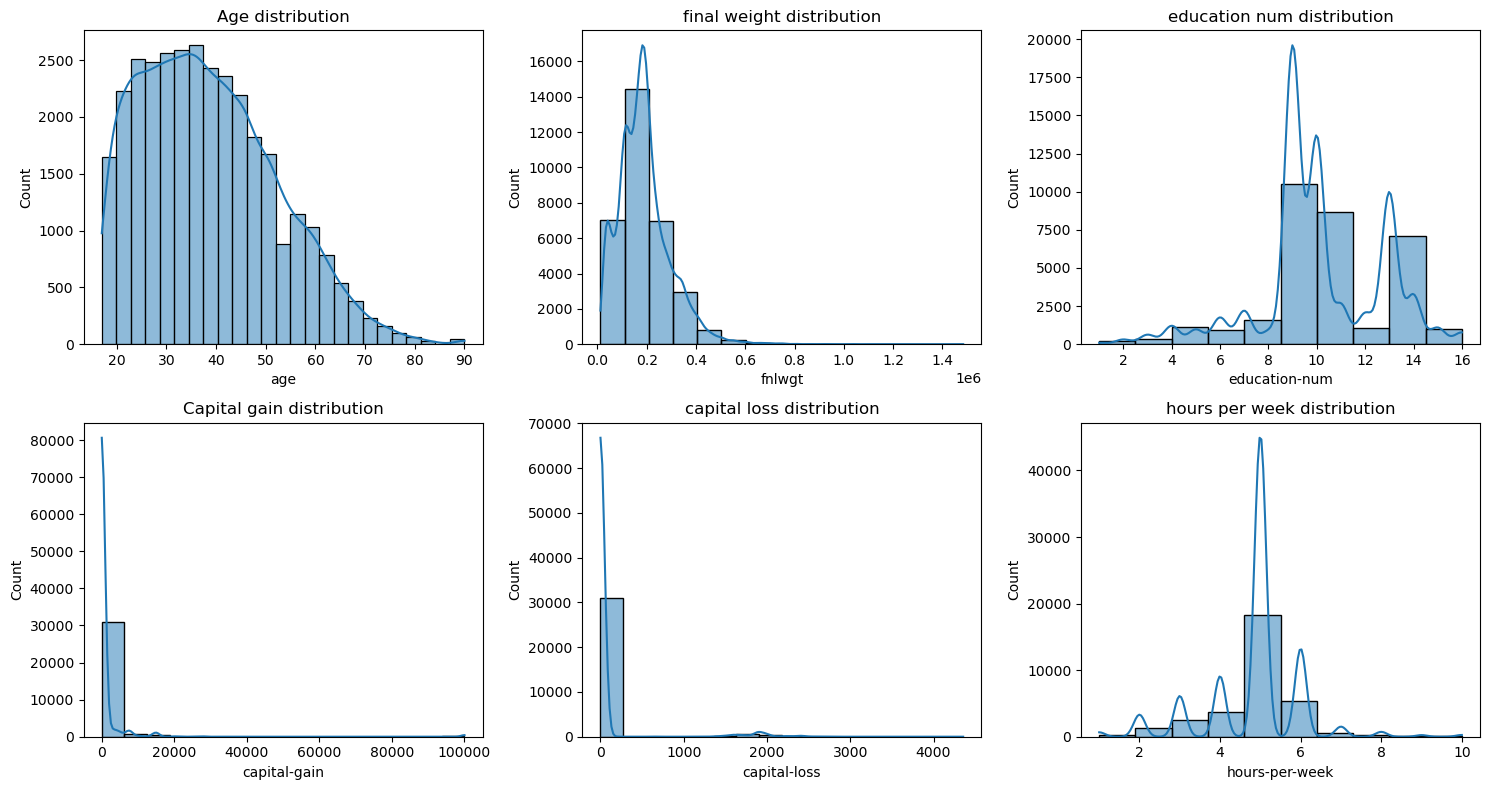

In [24]:
# Visual test for normality using histograms
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes=plt.subplots(2,3, figsize=(15,8))
axes=axes.flatten()
                       
sns.histplot(data=adult_df,x="age",kde=True,bins=25, ax=axes[0])
axes[0].set_title("Age distribution")

sns.histplot(data=adult_df,x="fnlwgt",kde=True, bins=15, ax=axes[1])
axes[1].set_title("final weight distribution")

sns.histplot(data=adult_df,x="education-num",kde=True, bins=10, ax=axes[2])
axes[2].set_title("education num distribution")

sns.histplot(data=adult_df,x="capital-gain",kde=True, ax=axes[3])
axes[3].set_title("Capital gain distribution")

sns.histplot(data=adult_df,x="capital-loss",kde=True, ax=axes[4])
axes[4].set_title("capital loss distribution")

sns.histplot(data=adult_df,x="hours-per-week",kde=True, bins=10, ax=axes[5])
axes[5].set_title("hours per week distribution")

plt.tight_layout()
plt.show()

In [25]:
#specify numeric columns
age=adult_df["age"]
fnlwgt=adult_df["fnlwgt"]
education_num=adult_df["education-num"]
capital_gain=adult_df["capital-gain"]
capital_loss=adult_df["capital-loss"]
hours_per_week=adult_df["hours-per-week"]
income=adult_df["income"]
income_binary=adult_df["income_binary"]

In [26]:
# Normality test - D'agonstions K^2 test
from scipy.stats import normaltest

stat,p=normaltest(age)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print ('Age is probably normally  distributed')
else:
    print('Age is probably NOT normally distributed')
print()

stat,p=normaltest(fnlwgt)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print ('fnlwgt is  probably normally distributed')
else:
    print('fnlwgt is probably NOT normally distributed')
print()

stat,p=normaltest(education_num)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print ('Education num is probably normally distributed')
else:
    print('Education num is probably NOT normally distributed')
print()

stat,p=normaltest(capital_gain)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print ('Capital gain is probably normally distributed')
else:
    print('Capital gain is probably NOT normally distributed')
print()

stat,p=normaltest(capital_loss)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print ('Capital loss is probably normally distributed')
else:
    print('Capital loss is NOT probably normally distributed')
print()

stat,p=normaltest(hours_per_week)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print ('Hours per week is probably normally distributed')
else:
    print('hours per week is probably NOT normally distributed')

stat=1521.807, p_value=0.000
Age is probably NOT normally distributed

stat=10657.411, p_value=0.000
fnlwgt is probably NOT normally distributed

stat=806.298, p_value=0.000
Education num is probably NOT normally distributed

stat=55034.455, p_value=0.000
Capital gain is probably NOT normally distributed

stat=29292.963, p_value=0.000
Capital loss is NOT probably normally distributed

stat=2647.389, p_value=0.000
hours per week is probably NOT normally distributed


### Correlation test

<Axes: >

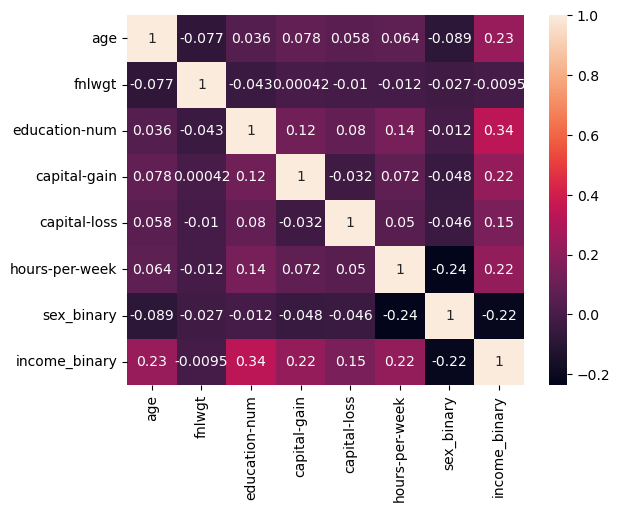

In [27]:
# Visualise Correlation using a heatmap
numeric_cols=['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week','sex_binary','income_binary']
corr=adult_df[numeric_cols].corr()
sns.heatmap(corr, annot=True)

In [28]:
corr_income=corr['income_binary'].sort_values(ascending=False)
print("\n Variable correlation with income \n", corr_income)


 Variable correlation with income 
 income_binary     1.000000
education-num     0.335264
age               0.233956
capital-gain      0.223330
hours-per-week    0.222430
capital-loss      0.150486
fnlwgt           -0.009527
sex_binary       -0.215917
Name: income_binary, dtype: float64


- The correlation analysis shows that educational level has the strongest positive association with income (0.335), followed by age , capital gain and hours per week, which all have weak positive correlations. Final weight has no correlation with income (0.009). Sex has a weak negative corelation with income suggesting that there are gender differences in income distribution. Overall, education has the strongest association with the level of income

In [29]:
#Spearman rank correlation test
from scipy.stats import spearmanr

print("\n Income correlation:\n")

stat,p=spearmanr(income_binary, education_num)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print("income and education are independent")
else:
    print("income and education are dependent")
print()

stat,p=spearmanr(income_binary, age)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print("income and age are independent")
else:
    print("income and age are dependent")
print()

stat,p=spearmanr(income_binary, capital_loss)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print("income and capital-loss are independent")
else:
    print("income and capital-loss are dependent")
print()

stat,p=spearmanr(income_binary, capital_gain)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print("income and capital-gain are independent")
else:
    print("income and capital-gain are dependent")
print()

stat,p=spearmanr(income_binary, hours_per_week)
print(f'stat={stat:.3f}, p_value={p:.3f}')
if p > 0.05:
    print("income and hours-per-week are independent")
else:
    print("income and hours-per-week are dependent")
print()


 Income correlation:

stat=0.330, p_value=0.000
income and education are dependent

stat=0.273, p_value=0.000
income and age are dependent

stat=0.141, p_value=0.000
income and capital-loss are dependent

stat=0.278, p_value=0.000
income and capital-gain are dependent

stat=0.255, p_value=0.000
income and hours-per-week are dependent



In [30]:
#categorical variables
work_class=adult_df["workclass"]
marital_status=adult_df["marital-status"]
occupation=adult_df["occupation"]
relationship=adult_df["relationship"]
race=adult_df["race"]
sex=adult_df["sex"]
continent=adult_df["Continent"]

In [31]:
#chi-squared test for categorical variables
from scipy.stats import chi2_contingency

print("\n Income correlation\n")

table=pd.crosstab(income,sex)
stat,p,dof,expected=chi2_contingency(table)
print('stat=%.3f, p_value=%.3f' %(stat,p))
if p > 0.05:
    print("income and sex are probably independent")
else:
    print(" income and sex are probably dependent")
print ()

table=pd.crosstab(income,race)
stat,p,dof,expected=chi2_contingency(table)
print('stat=%.3f, p_value=%.3f' %(stat,p))
if p > 0.05:
    print("income and race are probably independent")
else:
    print(" income and race are probably dependent")
print ()

table=pd.crosstab(income,education_num)
stat,p,dof,expected=chi2_contingency(table)
print('stat=%.3f, p_value=%.3f' %(stat,p))
if p > 0.05:
    print("income and education are probably independent")
else:
    print(" income and education are probably dependent")
print ()

table=pd.crosstab(income,continent)
stat,p,dof,expected=chi2_contingency(table)
print('stat=%.3f, p_value=%.3f' %(stat,p))
if p > 0.05:
    print("income and continent are probably independent")
else:
    print(" income and continent are probably dependent")
print ()

table=pd.crosstab(income,marital_status)
stat,p,dof,expected=chi2_contingency(table)
print('stat=%.3f, p_value=%.3f' %(stat,p))
if p > 0.05:
    print("income and marital-status are probably independent")
else:
    print(" income and marital-status are probably dependent")
print ()

table=pd.crosstab(income,occupation)
stat,p,dof,expected=chi2_contingency(table)
print('stat=%.3f, p_value=%.3f' %(stat,p))
if p > 0.05:
    print("income and occupation are probably independent")
else:
    print(" income and occupation are probably dependent")
print ()

table=pd.crosstab(income,relationship)
stat,p,dof,expected=chi2_contingency(table)
print('stat=%.3f, p_value=%.3f' %(stat,p))
if p > 0.05:
    print("income and relationship are probably independent")
else:
    print(" income and relationship are probably dependent") 
print ()

table=pd.crosstab(income,work_class)
stat,p,dof,expected=chi2_contingency(table)
print('stat=%.3f, p_value=%.3f' %(stat,p))
if p > 0.05:
    print("income and workclass are probably independent")
else:
    print(" income and workclass are probably dependent")


 Income correlation

stat=1515.568, p_value=0.000
 income and sex are probably dependent

stat=331.113, p_value=0.000
 income and race are probably dependent

stat=4427.160, p_value=0.000
 income and education are probably dependent

stat=36.186, p_value=0.000
 income and continent are probably dependent

stat=6508.120, p_value=0.000
 income and marital-status are probably dependent

stat=3197.391, p_value=0.000
 income and occupation are probably dependent

stat=6689.815, p_value=0.000
 income and relationship are probably dependent

stat=921.874, p_value=0.000
 income and workclass are probably dependent


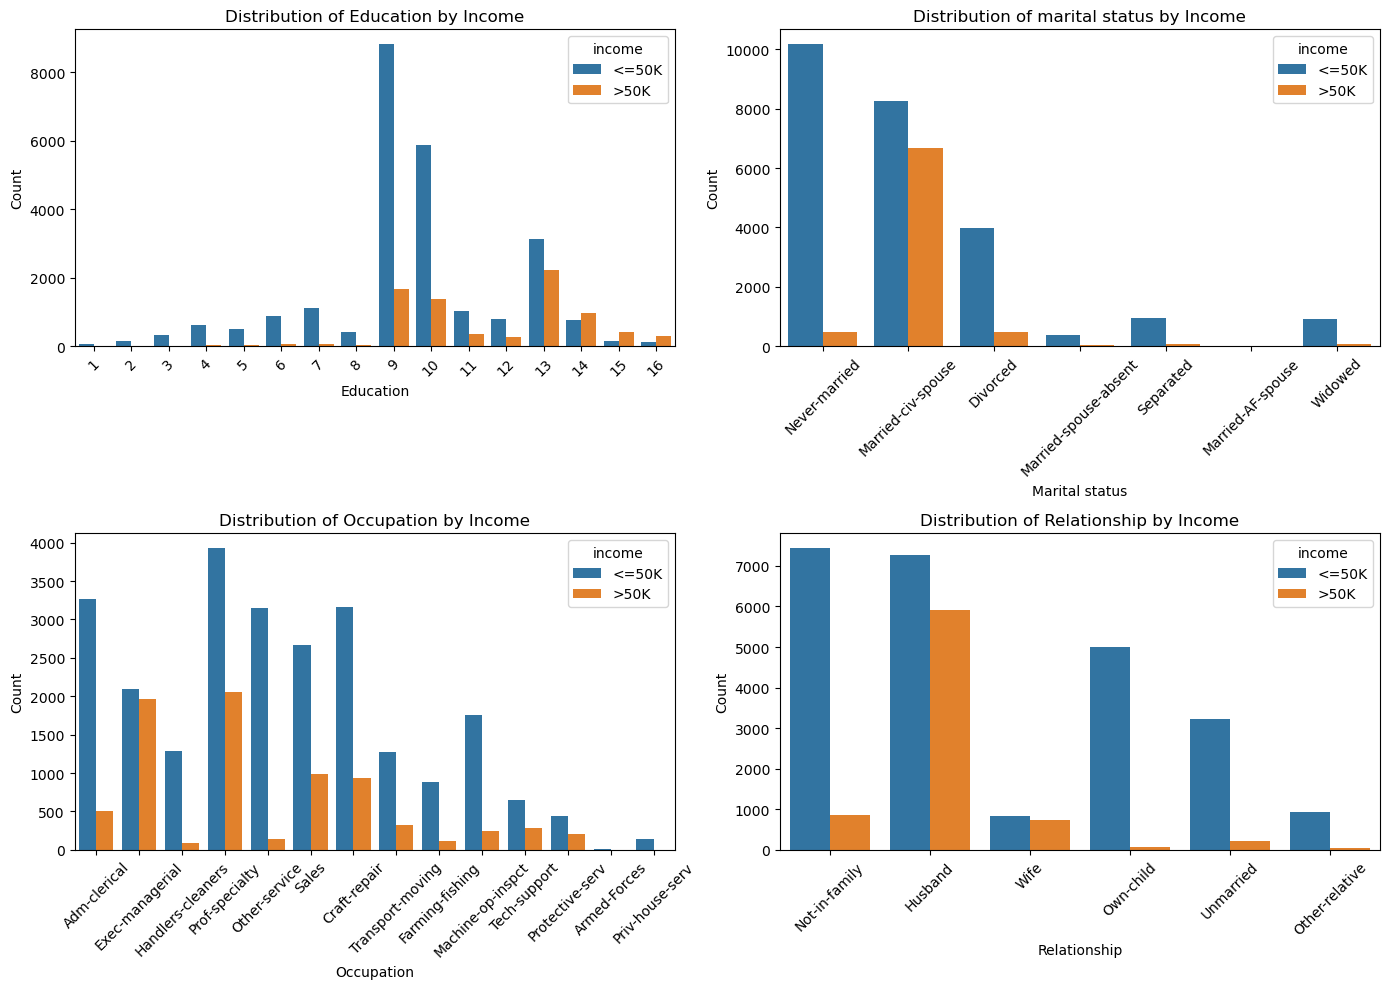

In [32]:
# Create a figure with 2 rows and 2 columns of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: education-num vs Income
sns.countplot(data=adult_df, x="education-num", hue="income", ax=axes[0,0])
axes[0,0].set_title("Distribution of Education by Income")
axes[0,0].set_xlabel("Education")
axes[0,0].set_ylabel("Count")
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Marital-status vs Income
sns.countplot(data=adult_df, x="marital-status", hue="income", ax=axes[0,1])
axes[0,1].set_title("Distribution of marital status by Income")
axes[0,1].set_xlabel("Marital status")
axes[0,1].set_ylabel("Count")
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Occupation vs Income
sns.countplot(data=adult_df, x="occupation", hue="income", ax=axes[1,0])
axes[1,0].set_title("Distribution of Occupation by Income")
axes[1,0].set_xlabel("Occupation")
axes[1,0].set_ylabel("Count")
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Relationship vs Income
sns.countplot(data=adult_df, x="relationship", hue="income", ax=axes[1,1])
axes[1,1].set_title("Distribution of Relationship by Income")
axes[1,1].set_xlabel("Relationship")
axes[1,1].set_ylabel("Count")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- From the bar plots above, those with higher levels of education are able to secure higher paying jobs compared to those with lower levels of education. Furthermore, those in a marital status ('married civ spouse') may have higher levels of income due to split bills, compared to those who have never married or are divorced. Similarly, those not in a family and are own children have less income compared to husband and wives as there is more economic support in family structures, as members may benefit from shared resources. Certain occupations such as 'exec-managarial' and 'prof-speciality' pay more income compared to manual jobs like 'handler-cleaner' and 'craft repair'.

### Homogenity of variance

In [33]:
from scipy.stats import levene

low_income=adult_df[adult_df['income_binary']==0] #<=50K
high_income=adult_df[adult_df['income_binary']==1]#>50K

#Age
stat,p=levene(low_income['age'],high_income['age'],center='median')
print(f"Age levene test: stat={stat:.3f}, p_value={p:.3f}")
if p > 0.05:
    print("The variance of age is equal across all income groups")
else:
    print(" The variance of age is NOT equal across all income groups") 
print ()

#fnlwgt
stat,p=levene(low_income['fnlwgt'],high_income['fnlwgt'],center='median')
print(f"Fnlwgt levene test: stat={stat:.3f}, p_value={p:.3f}")
if p > 0.05:
    print("The variance of fnlwgt is equal across all income groups")
else:
    print(" The variance of fnlwgt is NOT equal across all income groups") 
print ()

#Education-num
stat,p=levene(low_income['education-num'],high_income['education-num'],center='median')
print(f"Education-num levene test: stat={stat:.3f}, p_value={p:.3f}")
if p > 0.05:
    print("The variance of education-num is equal across all income groups")
else:
    print(" The variance of education-num is NOT equal across all income groups") 
print ()

#capital-gain
stat,p=levene(low_income['capital-gain'],high_income['capital-gain'],center='median')
print(f"Capital gain levene test: stat={stat:.3f}, p_value={p:.3f}")
if p > 0.05:
    print("The variance of capital-gain is equal across all income groups")
else:
    print(" The variance of capital-gain is NOT equal across all income groups") 
print ()

#capital-loss
stat,p=levene(low_income['capital-loss'],high_income['capital-loss'],center='median')
print(f"Capital loss levene test: stat={stat:.3f}, p_value={p:.3f}")
if p > 0.05:
    print("The variance of capital-loss is equal across all income groups")
else:
    print(" The variance of capital-loss is NOT equal across all income groups") 
print ()

#capital-loss
stat,p=levene(low_income['hours-per-week'],high_income['hours-per-week'],center='median')
print(f"Hours per week levene test: stat={stat:.3f}, p_value={p:.3f}")
if p > 0.05:
    print("The variance of hours-per-week is equal across all income groups")
else:
    print(" The variance of hours-per-week is NOT equal across all income groups") 

Age levene test: stat=700.165, p_value=0.000
 The variance of age is NOT equal across all income groups

Fnlwgt levene test: stat=12.357, p_value=0.000
 The variance of fnlwgt is NOT equal across all income groups

Education-num levene test: stat=291.866, p_value=0.000
 The variance of education-num is NOT equal across all income groups

Capital gain levene test: stat=1707.641, p_value=0.000
 The variance of capital-gain is NOT equal across all income groups

Capital loss levene test: stat=753.747, p_value=0.000
 The variance of capital-loss is NOT equal across all income groups

Hours per week levene test: stat=98.119, p_value=0.000
 The variance of hours-per-week is NOT equal across all income groups


In [34]:
adult_df=adult_df.drop(["income_binary","sex_binary"],axis=1)

### Group mean comparison

In [35]:
from scipy.stats import mannwhitneyu

#Two groups: Low income (<=50K) and high income (>50K)

#Age
stat,p=mannwhitneyu(low_income['age'],high_income['age'])
print(f"Age : stat={stat:.3f}, p_value{p:.3f}")
if p <0.05:
    print("Significant difference in the distribution of age between income groups")
else:
    print("No significant difference in the distribution of age between income groups")
print()

#fnlwgt
stat,p=mannwhitneyu(low_income['fnlwgt'],high_income['fnlwgt'])
print(f"fnlwgt : stat={stat:.3f}, p_value{p:.3f}")
if p <0.05:
    print("Significant difference in the distribution of fnlwht between income groups")
else:
    print("No significant difference in the distribution of fnlwgt between income groups")
print()

#education-num
stat,p=mannwhitneyu(low_income['education-num'],high_income['education-num'])
print(f"Education-num : stat={stat:.3f}, p_value{p:.3f}")
if p <0.05:
    print("Significant difference in the distribution of education-num between income groups")
else:
    print("No significant difference in the distribution of education-num between income groups")
print()

#capital-gain
stat,p=mannwhitneyu(low_income['capital-gain'],high_income['capital-gain'])
print(f"Capital-gain : stat={stat:.3f}, p_value{p:.3f}")
if p <0.05:
    print("Significant difference in the distribution of capital-gain between income groups")
else:
    print("No significant difference in the distribution of caital-gain between income groups")
print()

#capital-loss
stat,p=mannwhitneyu(low_income['capital-loss'],high_income['capital-loss'])
print(f"Capital-loss : stat={stat:.3f}, p_value{p:.3f}")
if p <0.05:
    print("Significant difference in the distribution of capital-loss between income groups")
else:
    print("No significant difference in the distribution of capital-loss between income groups")
print()

#Hours per week
stat,p=mannwhitneyu(low_income['hours-per-week'],high_income['hours-per-week'])
print(f"Hours-per-week: stat={stat:.3f}, p_value{p:.3f}")
if p <0.05:
    print("Significant difference in the distribution of hours-per-week between income groups")
else:
    print("No significant difference in the distribution of hours-per-week between income groups")
print()

Age : stat=61147481.500, p_value0.000
Significant difference in the distribution of age between income groups

fnlwgt : stat=98197653.500, p_value0.051
No significant difference in the distribution of fnlwgt between income groups

Education-num : stat=54774447.000, p_value0.000
Significant difference in the distribution of education-num between income groups

Capital-gain : stat=79362541.000, p_value0.000
Significant difference in the distribution of capital-gain between income groups

Capital-loss : stat=90049441.500, p_value0.000
Significant difference in the distribution of capital-loss between income groups

Hours-per-week: stat=66693239.000, p_value0.000
Significant difference in the distribution of hours-per-week between income groups



## Part 2: Machine learning modelling

### Pre-processing 

In [36]:
#Select columns with object datatypes
categorical_columns=adult_df.select_dtypes(include=['object']).columns.tolist()
categorical_columns

['workclass',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'income',
 'Continent']

In [37]:
#convert categorical variables into numerical variables (one hot encoding)
from sklearn.preprocessing import OneHotEncoder

categorical_columns= ['workclass','marital-status','occupation','relationship','race','Continent']

#create instance of one-hot-encoder
encoder=OneHotEncoder(handle_unknown='ignore')

#perform one-hot-encoding on categorical coolumns
encoded_array_train=encoder.fit_transform(adult_df[categorical_columns]).toarray()
encoded_array_test=encoder.transform(adult_test[categorical_columns]).toarray()

#Create a dataframe with proper column names and matching index
encoded_df_train=pd.DataFrame(encoded_array_train, columns=encoder.get_feature_names_out(categorical_columns),index=adult_df.index)
encoded_df_test=pd.DataFrame(encoded_array_test, columns=encoder.get_feature_names_out(categorical_columns),index=adult_test.index)

#drop the original columns and add the encoded ones
adult_train=pd.concat([adult_df.drop(categorical_columns,axis=1),encoded_df_train],axis=1)
adult_test=pd.concat([adult_test.drop(categorical_columns,axis=1),encoded_df_test],axis=1)                                         

In [38]:
#convert income and sex column to binary form
pd.set_option('future.no_silent_downcasting',True)

#remove punctuation from the income column in the test dataset
adult_test['income']=adult_test['income'].str.strip().str.replace('.','',regex=False)

target={'<=50K':0,'>50K':1}
adult_train['income']=adult_train['income'].replace(target).astype(int)
adult_test['income']=adult_test['income'].replace(target).astype(int)

gender={'Male':0,'Female':1}
adult_train['sex']=adult_train['sex'].replace(gender).astype(int)
adult_test['sex']=adult_test['sex'].replace(gender).astype(int)

In [39]:
#standardising data
from sklearn import preprocessing

stnorm=preprocessing.RobustScaler()

#standardise only the numeric columns
numeric_columns=["age","fnlwgt","education-num","capital-gain","capital-loss","hours-per-week"]

scaled_train_values=stnorm.fit_transform(adult_train[numeric_columns])
scaled_test_values=stnorm.transform(adult_test[numeric_columns])

#create a dataframe with the same index and column names
scaled_trained_df=pd.DataFrame(scaled_train_values,columns=numeric_columns,index=adult_train.index)
scaled_test_df=pd.DataFrame(scaled_test_values,columns=numeric_columns,index=adult_test.index)

#replace the original numeric columns with the standardised ones
adult_train[numeric_columns]=scaled_trained_df
adult_test[numeric_columns]=scaled_test_df

### Model building

In [40]:
import sklearn
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay,roc_curve,auc
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score,RandomizedSearchCV
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix, ConfusionMatrixDisplay

In [41]:
#Training dataset(adult.data)
x_train=adult_train.drop("income",axis=1) #features
y_train=adult_train["income"] #target

In [42]:
#test dataset(adult.test)
x_test=adult_test.drop("income",axis=1)#features
y_test=adult_test["income"]#target

In [43]:
rf=RandomForestClassifier(random_state=42)

#RF hyperparameter grid
param_grid={'n_estimators':[50,100,200],
            'max_depth':[None,5,10,15,25],
            'min_samples_split':[2,5,10],
            'max_features':['sqrt','log2',None]}

#stratifiedKfold for cross validation
skf=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

#Set up randomised searchCV
rand_search=RandomizedSearchCV(estimator=rf,
                               param_distributions=param_grid,
                               scoring='accuracy',
                               cv=skf,n_jobs=-1,verbose=1,
                               random_state=42)

#run randomised search
rand_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15, 25],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy', verbose=1)

In [44]:
#Best parameters and score
print("\nBest Parameters:\n",rand_search.best_params_)
print("\nbest k-fold CV accuracy:\n",rand_search.best_score_)
best_model=rand_search.best_estimator_


Best Parameters:
 {'n_estimators': 200, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 25}

best k-fold CV accuracy:
 0.8638569610603086


In [45]:
#Evaluate the best model on adult.test dataset
RF_y_pred=best_model.predict(x_test)
Test_accuracy=accuracy_score(y_test,RF_y_pred)
print("\nTest accuracy:\n", Test_accuracy)

# classification report
print("\n Random Forest Classification Report:\n", classification_report(y_test, RF_y_pred))


Test accuracy:
 0.8638849628218521

 Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     12427
           1       0.77      0.60      0.68      3846

    accuracy                           0.86     16273
   macro avg       0.83      0.77      0.79     16273
weighted avg       0.86      0.86      0.86     16273



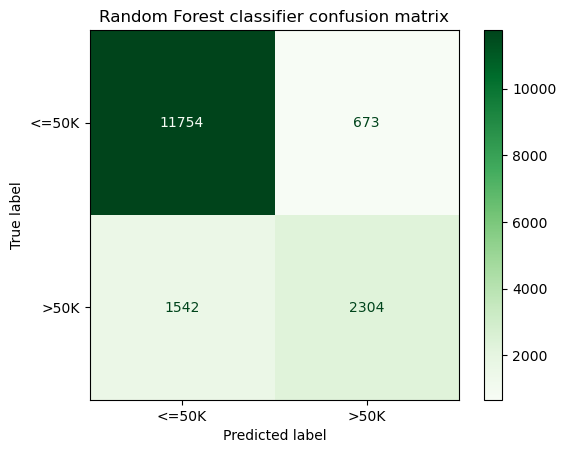

In [46]:
#RF confusion  matrix
rf_cm=confusion_matrix(y_test,RF_y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels=['<=50K','>50K'])
disp.plot(cmap='Greens')
plt.title("Random Forest classifier confusion matrix")
plt.show()

In [47]:
log_reg=LogisticRegression(random_state=42)

# LR hyperparemeter tuning
param_grid=[{'solver':['lbfgs','newton-cg'],
             'penalty':['l2'],
             'C':np.logspace(-4,4,20)}]

#stratifiedKfold for cross validation
skf=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

reg_rand_search=RandomizedSearchCV(log_reg,param_distributions=param_grid,cv=skf,verbose=1,n_jobs=-1,random_state=42, scoring="accuracy")

reg_rand_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LogisticRegression(random_state=42), n_jobs=-1,
                   param_distributions=[{'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                         'penalty': ['l2'],
                                         'solver': ['lbfgs', 'newton-cg']}],
                   random_state=42, scoring='accuracy', verbose=1)

In [48]:
#Best parameters and score
print("\nBest Parameters:\n",reg_rand_search.best_params_)
print("\nbest k-fold CV accuracy:\n",reg_rand_search.best_score_)
LR_best_model=reg_rand_search.best_estimator_


Best Parameters:
 {'solver': 'newton-cg', 'penalty': 'l2', 'C': np.float64(3792.690190732246)}

best k-fold CV accuracy:
 0.8504855727504976


In [49]:
#Evaluate the best model on the test dataset
LR_y_pred=LR_best_model.predict(x_test)
Test_accuracy=accuracy_score(y_test,LR_y_pred)
print("\nTest accuracy:\n", Test_accuracy)

# classification report
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, LR_y_pred))


Test accuracy:
 0.8523320838198243

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91     12427
           1       0.73      0.59      0.66      3846

    accuracy                           0.85     16273
   macro avg       0.81      0.76      0.78     16273
weighted avg       0.85      0.85      0.85     16273



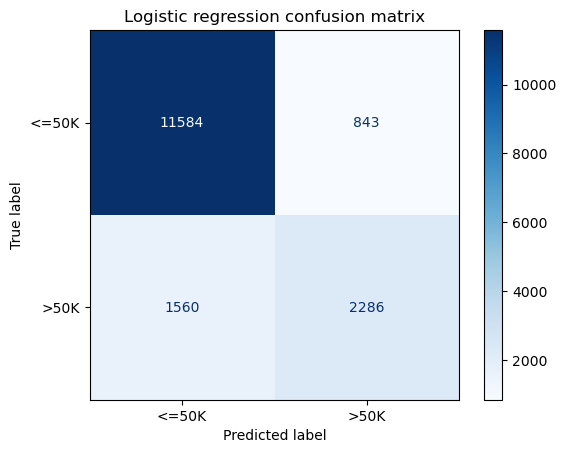

In [50]:
#LG confusion  matrix
rf_cm=confusion_matrix(y_test,LR_y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels=['<=50K','>50K'])
disp.plot(cmap='Blues')
plt.title("Logistic regression confusion matrix")
plt.show()

In [51]:
from sklearn.tree import DecisionTreeClassifier
ada=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                       random_state=42)

# Ada hyperparameter tuning
param_grid={'n_estimators':[100,200,300],
            'learning_rate':[0.5,1.0,2.0],
            'estimator__min_samples_split': [2, 5, 10],
            'estimator__min_samples_leaf': [1, 2, 5]}

#stratifiedKfold for cross validation
skf=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

#Set up randomised searchCV
ada_rand_search=RandomizedSearchCV(estimator=ada,param_distributions=param_grid,scoring='accuracy',cv=skf,n_jobs=-1,verbose=1)

#run randomised search
ada_rand_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                                random_state=42),
                   n_jobs=-1,
                   param_distributions={'estimator__min_samples_leaf': [1, 2,
                                                                        5],
                                        'estimator__min_samples_split': [2, 5,
                                                                         10],
                                        'learning_rate': [0.5, 1.0, 2.0],
                                        'n_estimators': [100, 200, 300]},
                   scoring='accuracy', verbose=1)

In [52]:
#Best parameters and score
print("\nBest Parameters:\n",ada_rand_search.best_params_)
print("\nbest k-fold CV accuracy:\n",ada_rand_search.best_score_)
ada_best_model=ada_rand_search.best_estimator_


Best Parameters:
 {'n_estimators': 300, 'learning_rate': 1.0, 'estimator__min_samples_split': 5, 'estimator__min_samples_leaf': 1}

best k-fold CV accuracy:
 0.8573403108978951


In [53]:
#Evaluate the best model on adult.test dataset
ada_y_pred=ada_best_model.predict(x_test)
Test_accuracy=accuracy_score(y_test,ada_y_pred,)
print("\nTest accuracy:\n", Test_accuracy)

# classification report
print("\nAda boost Classification Report:\n", classification_report(y_test, ada_y_pred))


Test accuracy:
 0.8574325569962514

Ada boost Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     12427
           1       0.77      0.57      0.65      3846

    accuracy                           0.86     16273
   macro avg       0.82      0.76      0.78     16273
weighted avg       0.85      0.86      0.85     16273



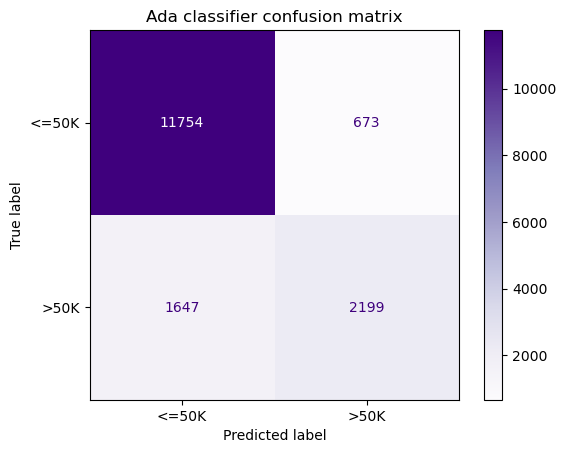

In [54]:
#Ada boost confusion  matrix
rf_cm=confusion_matrix(y_test,ada_y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels=['<=50K','>50K'])
disp.plot(cmap='Purples')
plt.title("Ada classifier confusion matrix")
plt.show()

In [55]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from keras_tuner.tuners import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping

In [56]:
#Prevent the model from overfitting
early_stop=EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)

#Model building function
def build_NN(hp):
    model=Sequential()
    #Tune number of layers
    for i in range(hp.Int('num_layers',min_value=1,max_value=3)):
        model.add(Dense(units=hp.Int('units_'+str(i),min_value=32,max_value=128,step=32),activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer=hp.Choice('optimiser',values=['adam','sgd']),loss='binary_crossentropy',metrics=['accuracy'])
    return model

#initialising random search
tuner=RandomSearch(build_NN,objective='val_accuracy',max_trials=5,executions_per_trial=1, directory='hyperparam_tuning',project_name='income_prediction')

#NN hyperparameter tuning
tuner.search(x_train,
             y_train,
             epochs=10,
             validation_split=0.2,
             callbacks=[early_stop])

#fetching the best hyperparameters
best_hp=tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp)

#building the model with the best hyperparameters
NN_model=tuner.hypermodel.build(best_hp)

#training the final model
NN_model.fit(x_train,y_train,epochs=50,validation_split=0.2,callbacks=[early_stop])

Reloading Tuner from hyperparam_tuning\income_prediction\tuner0.json
Epoch 1/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8075 - loss: 2.8736 - val_accuracy: 0.8242 - val_loss: 0.7077
Epoch 2/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8252 - loss: 1.0718 - val_accuracy: 0.8366 - val_loss: 0.5977
Epoch 3/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8297 - loss: 0.8296 - val_accuracy: 0.8243 - val_loss: 0.6188
Epoch 4/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8325 - loss: 0.7354 - val_accuracy: 0.8303 - val_loss: 0.6292
Epoch 5/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8359 - loss: 0.6188 - val_accuracy: 0.8562 - val_loss: 0.3096
Epoch 6/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8383 - loss: 0.5451 - val_accuracy: 0.8494 - val_loss: 0.3188
Epoch 7/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8434 - loss: 0.4805 - val_accuracy: 0.8356 - val_loss: 0.3593
Epoch 8/50
814/814 ━━━━━━━━━━━━━━━━

In [57]:
#Evaluate the best model on adult.test dataset
NN_y_pred_probs= NN_model.predict(x_test)
NN_y_pred = (NN_y_pred_probs > 0.5).astype(int) 

Test_accuracy=accuracy_score(y_test,NN_y_pred)
print("\nTest accuracy:\n", Test_accuracy)

# classification report
print("\nNeural Network classification Report:\n", classification_report(y_test, NN_y_pred))

509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  

Test accuracy:
 0.8517790204633442

Neural Network classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90     12427
           1       0.71      0.64      0.67      3846

    accuracy                           0.85     16273
   macro avg       0.80      0.78      0.79     16273
weighted avg       0.85      0.85      0.85     16273



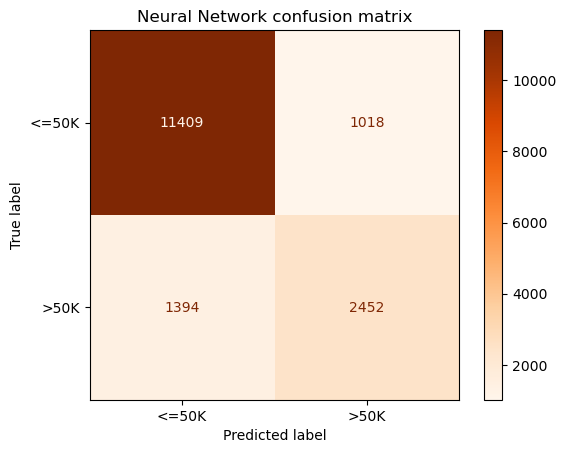

In [58]:
#Confusion matrix
cm=confusion_matrix(y_test,NN_y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['<=50K','>50K'])
disp.plot(cmap='Oranges')
plt.title("Neural Network confusion matrix")
plt.show()

### Model comparison

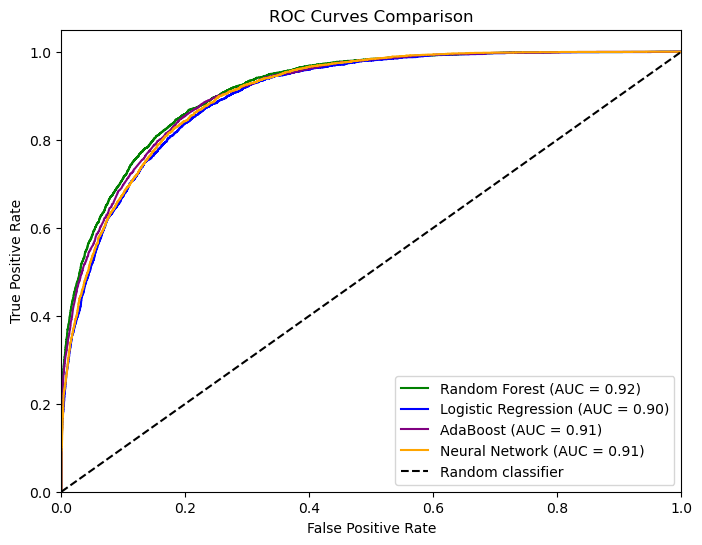

In [59]:
#RF 
y_test_proba=best_model.predict_proba(x_test)[:,1]
rf_fpr,rf_tpr,thresholds=metrics.roc_curve(y_test,y_test_proba)
RF_roc_auc=metrics.auc(rf_fpr,rf_tpr)

#LR
y_test_proba=LR_best_model.predict_proba(x_test)[:,1]
LR_fpr,LR_tpr,thresholds=metrics.roc_curve(y_test,y_test_proba)
LR_roc_auc=metrics.auc(LR_fpr,LR_tpr)

#Ada boost
y_test_proba=ada_best_model.predict_proba(x_test)[:,1]
Ada_fpr,Ada_tpr,thresholds=metrics.roc_curve(y_test,y_test_proba)
Ada_roc_auc=metrics.auc(Ada_fpr,Ada_tpr)

#NN
NN_fpr,NN_tpr,thresholds=metrics.roc_curve(y_test,NN_y_pred_probs)
NN_roc_auc=metrics.auc(NN_fpr,NN_tpr)

#Plot ROC-AUC curves 
plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, color='green', label='Random Forest (AUC = %0.2f)' % RF_roc_auc)
plt.plot(LR_fpr, LR_tpr, color='blue', label='Logistic Regression (AUC = %0.2f)' % LR_roc_auc)
plt.plot(Ada_fpr, Ada_tpr, color='purple', label='AdaBoost (AUC = %0.2f)' % Ada_roc_auc)
plt.plot(NN_fpr, NN_tpr, color='orange', label='Neural Network (AUC = %0.2f)' % NN_roc_auc)

# Random baseline
plt.plot([0,1],[0,1],'k--', label='Random classifier')

plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.show()

In [60]:
#compare the perfromance metrics of the models
from sklearn.metrics import precision_score, recall_score,f1_score

RF_accuracy=accuracy_score(y_test,RF_y_pred)
RF_precision=precision_score(y_test,RF_y_pred)
RF_recall=recall_score(y_test,RF_y_pred)
RF_f1=f1_score(y_test,RF_y_pred)

LR_accuracy=accuracy_score(y_test,LR_y_pred)
LR_precision=precision_score(y_test,LR_y_pred)
LR_recall=recall_score(y_test,LR_y_pred)
LR_f1=f1_score(y_test,LR_y_pred)

Ada_accuracy=accuracy_score(y_test,ada_y_pred)
Ada_precision=precision_score(y_test,ada_y_pred)
Ada_recall=recall_score(y_test,ada_y_pred)
Ada_f1=f1_score(y_test,ada_y_pred)

NN_accuracy=accuracy_score(y_test,NN_y_pred)
NN_precision=precision_score(y_test,NN_y_pred)
NN_recall=recall_score(y_test,NN_y_pred)
NN_f1=f1_score(y_test,NN_y_pred)

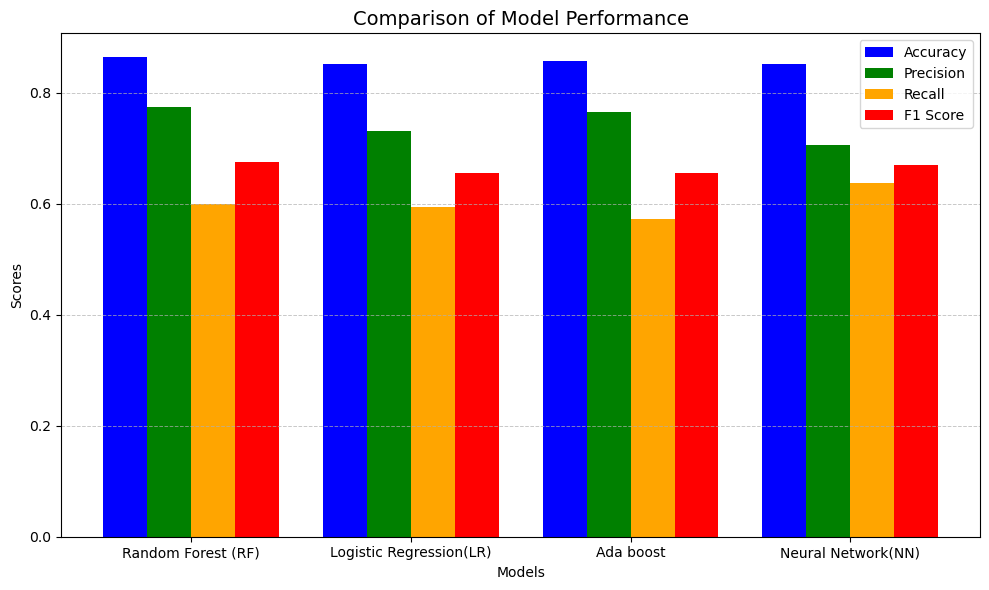

In [61]:
# Evaluation metrics for each model 
models = ['Random Forest (RF)', 'Logistic Regression(LR)', 'Ada boost','Neural Network(NN)']
accuracies = [RF_accuracy, LR_accuracy, Ada_accuracy,NN_accuracy]  
precisions = [RF_precision, LR_precision, Ada_precision,NN_precision]  
recalls = [RF_recall, LR_recall, Ada_recall,NN_recall]  
f1_scores = [RF_f1, LR_f1,Ada_f1,NN_f1]  

# Set the position of bars on X-axis
x = np.arange(len(models))

# Width of each bar
width = 0.2

# Plot the bar chart for accuracy, precision, recall, and F1 score
fig, ax = plt.subplots(figsize=(10, 6))

bar1 = ax.bar(x - width*1.5, accuracies, width, label='Accuracy', color='blue')
bar2 = ax.bar(x - width/2, precisions, width, label='Precision', color='green')
bar3 = ax.bar(x + width/2, recalls, width, label='Recall', color='orange')
bar4 = ax.bar(x + width*1.5, f1_scores, width, label='F1 Score', color='red')


#Add labels, title and legend
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Model Performance',fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)

#Add gridlines
ax.grid(True, which='both',axis='y',linestyle='--', linewidth=0.7, alpha=0.7)

# Show the plot
plt.tight_layout()
plt.legend()
plt.show()

## Part 3: Bias and fairness

In [62]:
from holisticai.bias.plots import group_pie_plot, histogram_plot, distribution_plot
from holisticai.bias.metrics import classification_bias_metrics

In [63]:
adult_train['sex'].value_counts()

sex
0    21774
1    10758
Name: count, dtype: int64

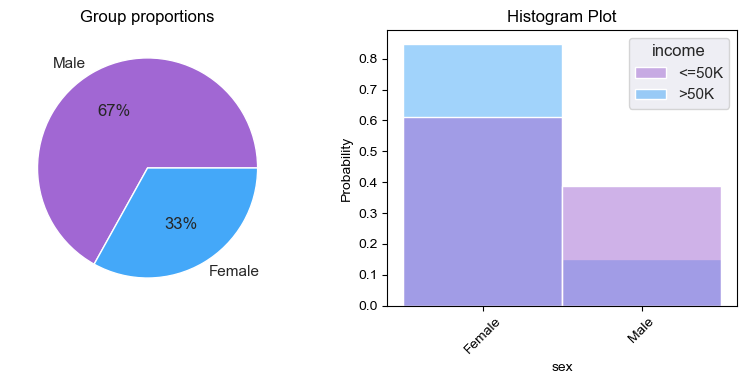

In [64]:
#sex attribute
attri_=adult_train['sex'].map({0: "Male", 1: "Female"})

#Target variable
y=adult_train['income']

fig1, ax=plt.subplots(1,2,figsize=(8,4))

#create a pie plot with the protected attribute
group_pie_plot(attri_, ax=ax[0])

#Create a histogram 
histogram_plot(adult_df['sex'],adult_df['income'],ax=ax[1])

plt.tight_layout()

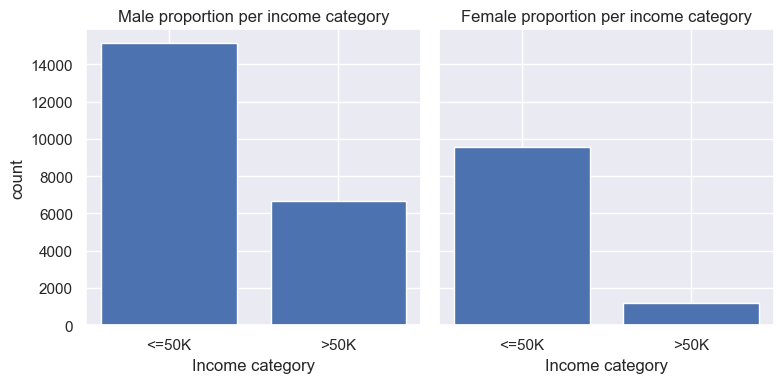

In [65]:
male_counts=adult_train[adult_train['sex']==0]['income'].value_counts()
female_counts=adult_train[adult_train['sex']==1]['income'].value_counts()

fig, axes=plt.subplots(1,2,figsize=(8,4), sharey=True)

#Male chart
axes[0].bar([0,1],male_counts.values)
axes[0].set_title('Male proportion per income category')
axes[0].set_xlabel('Income category')
axes[0].set_ylabel('count')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['<=50K','>50K'])

#Female chart
axes[1].bar([0,1],female_counts.values)
axes[1].set_title('Female proportion per income category')
axes[1].set_xlabel('Income category')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['<=50K','>50K'])

plt.tight_layout()
plt.show()

In [66]:
print('Male income', male_counts)
print('female income',female_counts)

Male income income
0    15114
1     6660
Name: count, dtype: int64
female income income
0    9579
1    1179
Name: count, dtype: int64


In [67]:
#ground truth
y_true=y_test.values

#define sensitive groups
group_a=(x_test['sex'] == 0).values # males
group_b=(x_test['sex'] == 1).values # females

#Evaluate bias metrics for models
RF=classification_bias_metrics(group_a,group_b,RF_y_pred,y_true,metric_type="both")
LR=classification_bias_metrics(group_a,group_b,LR_y_pred,y_true,metric_type="both")
Ada=classification_bias_metrics(group_a,group_b,ada_y_pred,y_true,metric_type="both")
NN=classification_bias_metrics(group_a,group_b,NN_y_pred,y_true,metric_type="both")

#Compute accuracy for the models
print("Random forest :",accuracy_score(y_test,RF_y_pred))
print("Logistic Regression :",accuracy_score(y_test,LR_y_pred))
print("Ada boost :",accuracy_score(y_test,ada_y_pred))
print("Neural Network :",accuracy_score(y_test,NN_y_pred))

keys=["Random Forest","Logistic Regression","Ada boost","Neural Network","Reference"]
comparison=pd.concat([RF['Value'],LR['Value'],Ada['Value'],NN['Value'],RF["Reference"]],axis=1)
comparison.columns=keys

def highlight_closest(s):
    reference = s['Reference']
    differences = s.drop('Reference').apply(lambda x: abs(x - reference))
    closest = differences.idxmin()
    return ['background-color: mediumseagreen' if x == s[closest] else '' for x in s]

comparison_highlighted = comparison.style.apply(highlight_closest, axis=1)
comparison_highlighted

Random forest : 0.8638849628218521
Logistic Regression : 0.8523320838198243
Ada boost : 0.8574325569962514
Neural Network : 0.8517790204633442


,Random Forest,Logistic Regression,Ada boost,Neural Network,Reference
Metric,,,,,
Statistical Parity,0.158942,0.179034,0.165036,0.190812,0
Disparate Impact,3.065868,3.456614,3.484710,3.219315,1
Four Fifths Rule,0.326172,0.289300,0.286968,0.310625,1
Cohen D,0.419047,0.465075,0.442196,0.477505,0
2SD Rule,24.717110,27.313449,26.027139,28.008726,0
Equality of Opportunity Difference,0.072970,0.113489,0.100783,0.096402,0
False Positive Rate Difference,0.054721,0.076759,0.063865,0.087264,0
Average Odds Difference,0.063845,0.095124,0.082324,0.091833,0
Accuracy Difference,-0.100903,-0.111586,-0.109748,-0.111586,0


### Class imbalance (SMOTE)

In [68]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline

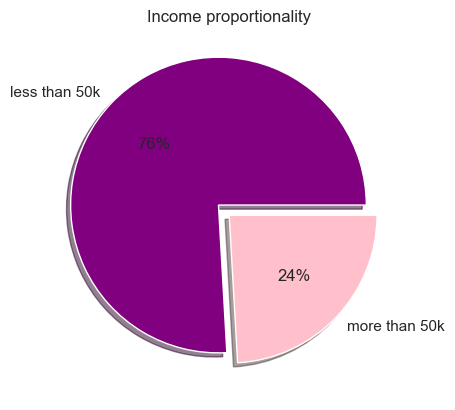

In [69]:
explode=(0.1,0)
colors=['purple','pink']
plt.pie(adult_df['income'].value_counts(), explode=explode,labels=['less than 50k','more than 50k'],colors=colors,autopct='%.f%%', shadow=True)
plt.title('Income proportionality')
plt.show()

In [70]:
#RF Pipeline to perfrom SMOTE
rf_pipeline=ImbPipeline([
    ('smote',SMOTE(random_state=42)),
    ('classifier',RandomForestClassifier(random_state=42))])

#define hyperparameter grid
param_grid={'classifier__n_estimators':[50,100,200],
            'classifier__max_depth':[None,5,10,15,25],
            'classifier__min_samples_split':[2,5,10],
            'classifier__max_features':['sqrt','log2',None]}

#stratifiedKfold for cross validation
skf=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

#Set up randomised searchCV
RF_search=RandomizedSearchCV(estimator=rf_pipeline,
                             param_distributions=param_grid,
                             scoring='accuracy',cv=skf,
                             n_jobs=-1,verbose=1,random_state=42)

#run randomised search
RF_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [None, 5, 10,
                                                                  15, 25],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [50, 100,
                                                                     200]},
                   random_state=42, scoring='accuracy', verbose=1)

In [71]:
#Evaluate the best model on adult.test dataset
RF_resampled_y_pred=best_model.predict(x_test)
Test_accuracy=accuracy_score(y_test,RF_resampled_y_pred)
print("\nTest accuracy:\n", Test_accuracy)

# classification report
print("\n Random Forest after SMOTE:\n", classification_report(y_test, RF_resampled_y_pred))


Test accuracy:
 0.8638849628218521

 Random Forest after SMOTE:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     12427
           1       0.77      0.60      0.68      3846

    accuracy                           0.86     16273
   macro avg       0.83      0.77      0.79     16273
weighted avg       0.86      0.86      0.86     16273



In [72]:
#LR Pipeline to perfrom SMOTE
lg_pipeline=ImbPipeline([
    ('smote',SMOTE(random_state=42)),
    ('classifier',LogisticRegression(random_state=42))])

#hyperparemeter tuning
param_grid=[{'classifier__solver':['lbfgs','newton-cg'],
             'classifier__penalty':['l2'],
             'classifier__C':np.logspace(-4,4,20),
             'classifier__max_iter':[500,1000,2000]}]

#stratifiedKfold for cross validation
skf=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

LR_search=RandomizedSearchCV(estimator=lg_pipeline,
                             param_distributions=param_grid,
                             cv=skf,verbose=1,n_jobs=-1,
                             random_state=42, scoring="accuracy")

LR_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('classifier',
                                              LogisticRegression(random_state=42))]),
                   n_jobs=-1,
                   param_distributions=[{'classifier__C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02...66790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                         'classifier__max_iter': [500, 1000,
                                                                  2000],
                                         'classifier__penalty': ['l2'],
                                         'classifier__solver': ['lbfgs',
                                                                'newton-cg']}],
                   random_state=42, scoring='accuracy', verbose=1)

In [73]:
#Best parameters and score
print("\nBest Parameters:\n",LR_search.best_params_)
print("\nbest k-fold CV accuracy:\n",LR_search.best_score_)
LR_best_model=LR_search.best_estimator_


Best Parameters:
 {'classifier__solver': 'lbfgs', 'classifier__penalty': 'l2', 'classifier__max_iter': 2000, 'classifier__C': np.float64(0.0001)}

best k-fold CV accuracy:
 0.8089878567719004


In [74]:
#Evaluate the best model on the test dataset
LR_resampled_y_pred=LR_best_model.predict(x_test)
Test_accuracy=accuracy_score(y_test,LR_resampled_y_pred)
print("\nTest accuracy:\n", Test_accuracy)

# classification report
print("\nLogistic Regression after SMOTE:\n", classification_report(y_test, LR_resampled_y_pred))


Test accuracy:
 0.806550728200086

Logistic Regression after SMOTE:
               precision    recall  f1-score   support

           0       0.92      0.82      0.87     12427
           1       0.57      0.76      0.65      3846

    accuracy                           0.81     16273
   macro avg       0.74      0.79      0.76     16273
weighted avg       0.83      0.81      0.82     16273



In [75]:
from sklearn.tree import DecisionTreeClassifier

ada=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),random_state=42)

#Ada Pipeline to perfrom SMOTE
Ada_pipeline=ImbPipeline([
    ('smote',SMOTE(random_state=42)),
    ('classifier',ada)])

#Tune hyperparameters
param_grid={'classifier__n_estimators':[100,200,300],
            'classifier__learning_rate':[0.5,1.0,2.0],
            'classifier__estimator__min_samples_split': [2, 5, 10],
            'classifier__estimator__min_samples_leaf': [1, 2, 5]
            }

#stratifiedKfold for cross validation
skf=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

#Set up randomised searchCV
ada_search=RandomizedSearchCV(estimator=Ada_pipeline,
                              param_distributions=param_grid,
                              scoring='accuracy',cv=skf,
                              n_jobs=-1,verbose=1)

#run randomised search
ada_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('classifier',
                                              AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                                                 random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__estimator__min_samples_leaf': [1,
                                                                                    2,
                                                                                    5],
                                        'classifier__estimator__min_samples_split': [2,
                                                                                     5,
                                                                                     10],
                                        'classifier__learning_rate': [0.5, 1.0,
                                                                      2.0],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   scoring='accuracy', verbose=1)

In [76]:
#Best parameters and score
print("\nBest Parameters:\n",ada_search.best_params_)
print("\nbest k-fold CV accuracy:\n",ada_search.best_score_)
ada_best_model=ada_search.best_estimator_


Best Parameters:
 {'classifier__n_estimators': 300, 'classifier__learning_rate': 1.0, 'classifier__estimator__min_samples_split': 10, 'classifier__estimator__min_samples_leaf': 1}

best k-fold CV accuracy:
 0.8313659658819506


In [77]:
#Evaluate the best model on adult.test dataset
ada_resampled_y_pred=ada_best_model.predict(x_test)
Test_accuracy=accuracy_score(y_test,ada_resampled_y_pred)
print("\nTest accuracy:\n", Test_accuracy)

# classification report
print("\nAda boost after SMOTE:\n", classification_report(y_test, ada_resampled_y_pred))


Test accuracy:
 0.8331592207951822

Ada boost after SMOTE:
               precision    recall  f1-score   support

           0       0.93      0.84      0.89     12427
           1       0.61      0.80      0.69      3846

    accuracy                           0.83     16273
   macro avg       0.77      0.82      0.79     16273
weighted avg       0.86      0.83      0.84     16273



In [78]:
#class distribution before applting SMOTE in NN
print("Class distribution before SMOTE:", Counter(y_train))

#Apply SMOTE to oversample the minority class
smote=SMOTE(sampling_strategy='minority', random_state=42)
x_train_resampled,y_train_resampled=smote.fit_resample(x_train,y_train)

#class distribution after SMOTE
print("Class distribution after SMOTE:",Counter(y_train_resampled))

Class distribution before SMOTE: Counter({0: 24693, 1: 7839})
Class distribution after SMOTE: Counter({0: 24693, 1: 24693})


In [79]:
print("\nGender distribution after SMOTE:\n",x_train_resampled['sex'].value_counts())


Gender distribution after SMOTE:
 sex
0    36556
1    12830
Name: count, dtype: int64


In [80]:
#Prevent the model from overfitting
early_stop=EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)

#Model building function
def build_NN(hp):
    model=Sequential()
    #Tune number of layers
    for i in range(hp.Int('num_layers',min_value=1,max_value=3)):
        model.add(Dense(units=hp.Int('units_'+str(i),min_value=32,max_value=128,step=32),activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer=hp.Choice('optimiser',values=['adam','sgd']),loss='binary_crossentropy',metrics=['accuracy'])
    return model

#initialising random search
NN_tuner=RandomSearch(build_NN,objective='val_accuracy',max_trials=5,executions_per_trial=1, directory='hyperparam_tuning',project_name='income_prediction')

#performing hyperparameter tuning
NN_tuner.search(x_train_resampled,y_train_resampled,epochs=10,validation_split=0.2,callbacks=[early_stop])

#fetching the best hyperparameters
best_hp_NN=tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp_NN)

#building the model with the best hyperparameters
NN_model_resampled=NN_tuner.hypermodel.build(best_hp)

#training the final model
NN_model_resampled.fit(x_train_resampled,y_train_resampled,epochs=50,validation_split=0.2,callbacks=[early_stop])

Reloading Tuner from hyperparam_tuning\income_prediction\tuner0.json
Epoch 1/50
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7916 - loss: 3.7448 - val_accuracy: 0.7048 - val_loss: 0.5707
Epoch 2/50
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8094 - loss: 1.4345 - val_accuracy: 0.8024 - val_loss: 0.4119
Epoch 3/50
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8170 - loss: 0.9851 - val_accuracy: 0.7831 - val_loss: 0.4662
Epoch 4/50
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8225 - loss: 0.8294 - val_accuracy: 0.8546 - val_loss: 0.3419
Epoch 5/50
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8244 - loss: 0.7494 - val_accuracy: 0.8046 - val_loss: 0.4089
Epoch 6/50
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8271 - loss: 0.5652 - val_accuracy: 0.8075 - val_loss: 0.4608
Epoch 7/50
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8306 - loss: 0.4656 - val_accuracy: 0.7633 - val_loss: 0.4902
Epoch 8/50
1235/1235 

In [81]:
#Evaluate the best model on adult.test dataset
NN_y_pred_probs= NN_model_resampled.predict(x_test)
NN_resampled_y_pred = (NN_y_pred_probs > 0.5).astype(int) 

Test_accuracy=accuracy_score(y_test,NN_resampled_y_pred)
print("\nTest accuracy:\n", Test_accuracy)

# classification report
print("\nNeural Network classification Report:\n", classification_report(y_test, NN_resampled_y_pred))

509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  

Test accuracy:
 0.8083942727216862

Neural Network classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.87     12427
           1       0.57      0.82      0.67      3846

    accuracy                           0.81     16273
   macro avg       0.75      0.81      0.77     16273
weighted avg       0.85      0.81      0.82     16273



In [82]:
#Evaluate bias metrics for models
RF=classification_bias_metrics(group_a,group_b,RF_resampled_y_pred,y_true,metric_type="both")
LR=classification_bias_metrics(group_a,group_b,LR_resampled_y_pred,y_true,metric_type="both")
Ada=classification_bias_metrics(group_a,group_b,ada_resampled_y_pred,y_true,metric_type="both")
NN=classification_bias_metrics(group_a,group_b,NN_resampled_y_pred,y_true,metric_type="both")

#Compute accuracy for the models
print("Random forest :",accuracy_score(y_test,RF_resampled_y_pred))
print("Logistic Regression :",accuracy_score(y_test,LR_resampled_y_pred))
print("Ada boost :",accuracy_score(y_test,ada_resampled_y_pred))
print("Neural Network :",accuracy_score(y_test,NN_resampled_y_pred))

keys=["Random Forest","Logistic Regression","Ada boost","Neural Network","Reference"]
comparison=pd.concat([RF['Value'],LR['Value'],Ada['Value'],NN['Value'],RF["Reference"]],axis=1)
comparison.columns=keys

def highlight_closest(s):
    reference = s['Reference']
    differences = s.drop('Reference').apply(lambda x: abs(x - reference))
    closest = differences.idxmin()
    return ['background-color: mediumseagreen' if x == s[closest] else '' for x in s]

comparison_highlighted = comparison.style.apply(highlight_closest, axis=1)
comparison_highlighted

Random forest : 0.8638849628218521
Logistic Regression : 0.806550728200086
Ada boost : 0.8331592207951822
Neural Network : 0.8083942727216862


,Random Forest,Logistic Regression,Ada boost,Neural Network,Reference
Metric,,,,,
Statistical Parity,0.158942,0.325324,0.301264,0.267473,0
Disparate Impact,3.065868,4.352195,3.824998,2.641792,1
Four Fifths Rule,0.326172,0.229769,0.261438,0.378531,1
Cohen D,0.419047,0.742632,0.686090,0.585173,0
2SD Rule,24.717110,42.142780,39.249085,33.916254,0
Equality of Opportunity Difference,0.072970,0.321310,0.181485,0.089789,0
False Positive Rate Difference,0.054721,0.208758,0.187912,0.166578,0
Average Odds Difference,0.063845,0.265034,0.184699,0.128184,0
Accuracy Difference,-0.100903,-0.139011,-0.137291,-0.121585,0


### Accuracy comparison

In [83]:
# Accuracy before SMOTE
acc_before = {
    'Random Forest': accuracy_score(y_test, RF_y_pred),
    'Logistic Regression': accuracy_score(y_test, LR_y_pred),
    'AdaBoost': accuracy_score(y_test, ada_y_pred),
    'Neural Network': accuracy_score(y_test, NN_y_pred)}

# Accuracy after SMOTE
acc_after = {
    'Random Forest': accuracy_score(y_test, RF_resampled_y_pred),
    'Logistic Regression': accuracy_score(y_test, LR_resampled_y_pred),
    'AdaBoost': accuracy_score(y_test, ada_resampled_y_pred),
    'Neural Network': accuracy_score(y_test, NN_resampled_y_pred)}

acc_data = pd.DataFrame([acc_before, acc_after], index=['Before SMOTE', 'After SMOTE'])
acc_data = acc_data.map(lambda x: round(x, 4))
acc_data.loc['Diff. (%)'] = ((acc_data.loc['After SMOTE'] - acc_data.loc['Before SMOTE']) * 100).round(4)

acc_data

,Random Forest,Logistic Regression,AdaBoost,Neural Network
Before SMOTE,0.8639,0.8523,0.8574,0.8518
After SMOTE,0.8639,0.8066,0.8332,0.8084
Diff. (%),0.0000,-4.5700,-2.4200,-4.3400


#### Reference list

- Admin (2025). The Academic Papers UK. [online] The Academic Papers UK. Available at: https://www.theacademicpapers.co.uk/blog/2025/09/25/correlation-test-in-python/
- Bobbitt, Z. (2020). How to Perform Levene’s Test in Python. [online] Statology. Available at: https://www.statology.org/levenes-test-python/.
- Bobbitt, Z.(2018). Mann-Whitney U Test. [online] Statology. Available at: https://www.statology.org/mann-whitney-u-test/.
- Chen, V. (2021). Preventing Data Leakage: StandardScaler and SMOTE. [online] Medium. Available at: https://vch98.medium.com/preventing-data-leakage-standardscaler-and-smote-e7416c63259c.
- Chi-Square Test for Independence in Python with Examples from the IBM HR Analytics Dataset. [online] Medium. Available at: https://medium.com/data-science/chi-square-test-for-independence-in-python-with-examples-from-the-ibm-hr-analytics-dataset-97b9ec9bb80a
- Duarte, R. (2023). Class Weight, SMOTE, Random Over, and Under Sampling. [online] Medium. Available at: https://medium.com/@rafaelnduarte/class-weight-smote-random-over-and-under-sampling-bca603378e02.
- GeeksforGeeks (2019). Hyperparameter Tuning. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning/.
- GeeksforGeeks (2019). ML | Handle Missing Data with Simple Imputer. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/ml-handle-missing-data-with-simple-imputer/
- GeeksforGeeks (2020). pandas.crosstab() function in Python. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/python/pandas-crosstab-function-in-python/.
- GeeksforGeeks (2020). Spearman’s Rank Correlation. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/.
- GeeksforGeeks (2024). How to plot ROC curve in Python. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/how-to-plot-roc-curve-in-python/.
- GeeksforGeeks (2025). Normality Test. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/data-science/normality-test/.
- Hankare, O. (2023). Cross Validation. [online] Medium. Available at: https://ompramod.medium.com/cross-validation-623620ff84c2.
- Holistic AI (2024). holisticai.bias.mitigation — holisticai documentation. [online] Readthedocs.io. Available at: https://holisticai.readthedocs.io/en/latest/reference/bias/mitigation.html 
- Holistic AI (2024). Quickstart — holisticai documentation. [online] Readthedocs.io. Available at: https://holisticai.readthedocs.io/en/latest/getting_started/quickstart.html 
- Holistic AI. (2024). Measuring Bias in classification — holisticai documentation. [online] Readthedocs.io. Available at: https://holisticai.readthedocs.io/en/latest/gallery/tutorials/bias/measuring_bias/measuring_bias_classification.html 
- Ikegbo, S.O.(2025). Using Python to Mitigate Bias and Discrimination in Machine Learning Models. [online] Medium. Available at: https://medium.com/@stacymacbrains/using-python-to-mitigate-bias-and-discrimination-in-machine-learning-models-c66e2c411219.
- Kharche, A. (2025). The Data Scientist’s Guide to Scaling: Standard, MinMax & Robust Methods. [online] Medium. Available at: https://medium.com/@amitkharche14/the-data-scientists-guide-to-scaling-standard-minmax-robust-methods-25818b30c881.
- Olaniyan, O. (2025). Sklearn vs Imblearn Pipeline: Preventing Data Leakage in Imbalanced Datasets. [online] Medium. Available at: https://medium.com/@banjiolaniyan123/sklearn-vs-imblearn-pipeline-preventing-data-leakage-in-imbalanced-datasets-b4272484e985.
- Zhang, D. (2020).Mastering Hyperparameter Tuning for Neural Networks with Keras Tuner. [online] Medium. Available at: https://medium.com/@piyushkashyap045/mastering-hyperparameter-tuning-for-neural-networks-with-keras-tuner-c0b64d549188.
